# Solutions · 07 · Absorption, hitting times and random walks

Worked solutions to the exercises of [notebook 07](../notebooks/07_absorption_hitting_and_random_walks.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engstoch import markov as mk, walks as wk, models
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## Exercise 1

In snakes and ladders, which single snake would you remove to shorten the expected game the most? Compute the expected game length for each removal.

In [2]:
base = models.snakes_and_ladders()
E0 = base["chain"].absorption()["expected_steps"][0]
snakes = {k: v for k, v in base["jumps"].items() if v < k}
rows = []
for head in snakes:
    j = dict(base["jumps"]); del j[head]
    rows.append((f"{head} -> {snakes[head]}", models.snakes_and_ladders(jumps=j)["chain"].absorption()["expected_steps"][0]))
rows.sort(key=lambda t: t[1])
print(f"with all snakes: {E0:.3f} throws")
print(pd.DataFrame(rows, columns=["snake removed", "expected throws"]).to_string(index=False, float_format="%.3f"))

with all snakes: 20.374 throws
snake removed  expected throws
     35 -> 22           16.049
     31 -> 19           18.021
      17 -> 4           18.991
      12 -> 2           19.318
     14 -> 11           19.706


Each candidate board is a new absorbing chain, solved in microseconds. The most harmful snake is the one at 35,
one square before the finish: players near the end land on it often (a throw past 36 wastes the turn, so they
hover there), and it sends them back thirteen squares. Removing it shortens the expected game by more than four
throws; removing the equally long snake at 17 saves barely one.

## Exercise 2

Simulate 10^4 symmetric walks of 10^4 steps and plot the distribution of the time of the last visit to 0 divided by n. Compare with the arcsine law.

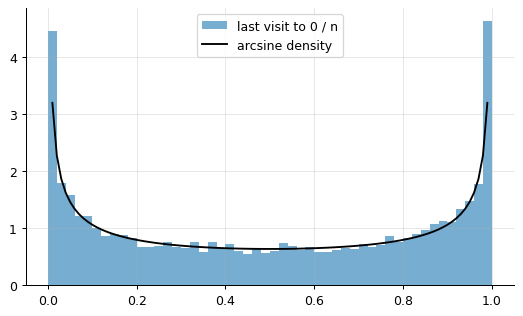

P(last zero before n/10): 0.2054  arcsine: 0.2048
P(last zero after 9n/10): 0.2062  arcsine: 0.2048


In [3]:
n = 10_000
w = wk.simple_walk(n, R(1), n_paths=10_000)
last_zero = np.array([np.flatnonzero(row == 0)[-1] for row in w]) / n
x = np.linspace(0, 1, 101)
plt.hist(last_zero, bins=50, density=True, alpha=0.6, label="last visit to 0 / n"); plt.plot(x[1:-1], 1 / (np.pi * np.sqrt(x[1:-1] * (1 - x[1:-1]))), "k", label="arcsine density"); plt.legend(); plt.show()
print("P(last zero before n/10):", np.mean(last_zero < 0.1).round(4), " arcsine:", round(float(wk.arcsine_cdf(0.1)), 4))
print("P(last zero after 9n/10):", np.mean(last_zero > 0.9).round(4), " arcsine:", round(1 - float(wk.arcsine_cdf(0.9)), 4))

Lévy's second arcsine law: the last return to zero is as likely to fall in the first tenth of the game as in
the last tenth, and either is far more likely than the middle tenth. A walk that has been ahead for most of a
long game is the rule, not a sign of skill.

## Exercise 3

**Implement it yourself:** count the n-step paths that stay strictly positive after step 0 and end at k by brute-force enumeration for n = 12, and check the ballot-theorem formula (k/n) C(n, (n+k)/2).

In [4]:
import itertools
n = 12
for k in (2, 4, 6):
    count = 0
    for steps in itertools.product((1, -1), repeat=n):
        s = np.cumsum(steps)
        if s[-1] == k and np.all(s > 0):
            count += 1
    formula = k / n * wk.paths_count(n, k)
    print(f"n = {n}, end at {k}: brute force {count}, ballot formula (k/n) C(n, (n+k)/2) = {formula:.0f}")

n = 12, end at 2: brute force 132, ballot formula (k/n) C(n, (n+k)/2) = 132
n = 12, end at 4: brute force 165, ballot formula (k/n) C(n, (n+k)/2) = 165
n = 12, end at 6: brute force 110, ballot formula (k/n) C(n, (n+k)/2) = 110


Of the C(n, (n+k)/2) paths ending at k, a fraction k/n stays strictly positive - the ballot theorem with
a − b = k votes of margin among a + b = n. Brute force over the 4096 paths confirms it.